In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment setup successful")

Environment setup successful


In [4]:
df = pd.read_csv('data/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# ==========================
# DATASET OVERVIEW
# ==========================

print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nStatistical summary:")
print(df.describe())

Shape of dataset:
(891, 12)

Column names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

Statistical summary:
       PassengerI

In [6]:
# 1. REMOVE DUPLICATES & DROP CABIN COLUMN

df = df.drop_duplicates()
print("✓ Duplicate rows handled.")

# Drop the Cabin column due to excessive missing data
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])
    print("✓ 'Cabin' column dropped successfully.")
else:
    print("! 'Cabin' column already removed or doesn't exist.")

✓ Duplicate rows handled.
✓ 'Cabin' column dropped successfully.


In [7]:
# 2. FILL MISSING VALUES


# Fill missing Age values with the median age
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print(f"✓ Missing Age values filled with median age: {median_age}")

# Fill missing Embarked values with the most frequent port (mode)
most_frequent_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_frequent_port)
print(f"✓ Missing Embarked values filled with mode: '{most_frequent_port}'")

✓ Missing Age values filled with median age: 28.0
✓ Missing Embarked values filled with mode: 'S'


In [8]:
# ==========================================
# 3. VERIFY CLEANING RESULTS
# ==========================================

print("Remaining Missing Values per Column:")
print(df.isnull().sum())

Remaining Missing Values per Column:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [9]:
# ==========================================
# OUTLIER DETECTION & REMOVAL (IQR METHOD)
# ==========================================

# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Define the normal upper and lower boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Normal Fare range calculated: Clear boundaries from ${lower_bound:.2f} to ${upper_bound:.2f}")

# 4. Filter the dataset to keep only normal values
df_cleaned = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]

print(f"Original dataset rows: {df.shape[0]}")
print(f"Rows remaining after outlier removal: {df_cleaned.shape[0]}")
print(f"Removed {df.shape[0] - df_cleaned.shape[0]} outlier rows.")

Normal Fare range calculated: Clear boundaries from $-26.72 to $65.63
Original dataset rows: 891
Rows remaining after outlier removal: 775
Removed 116 outlier rows.


In [11]:
# ==========================================
# SAVE THE CLEANED DATASET
# ==========================================

# Save to your root project folder
df_cleaned.to_csv('cleaned_titanic.csv', index=False)

print(" Success! 'cleaned_titanic.csv' has been generated and saved.")

 Success! 'cleaned_titanic.csv' has been generated and saved.


C:\Users\vinpi\AppData\Local\Temp\ipykernel_6088\414713293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df_cleaned, ax=axes[0], palette='Set2')
C:\Users\vinpi\AppData\Local\Temp\ipykernel_6088\414713293.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died', 'Survived'])
C:\Users\vinpi\AppData\Local\Temp\ipykernel_6088\414713293.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df_cleaned, ax=axes[1], palette='Pastel1')


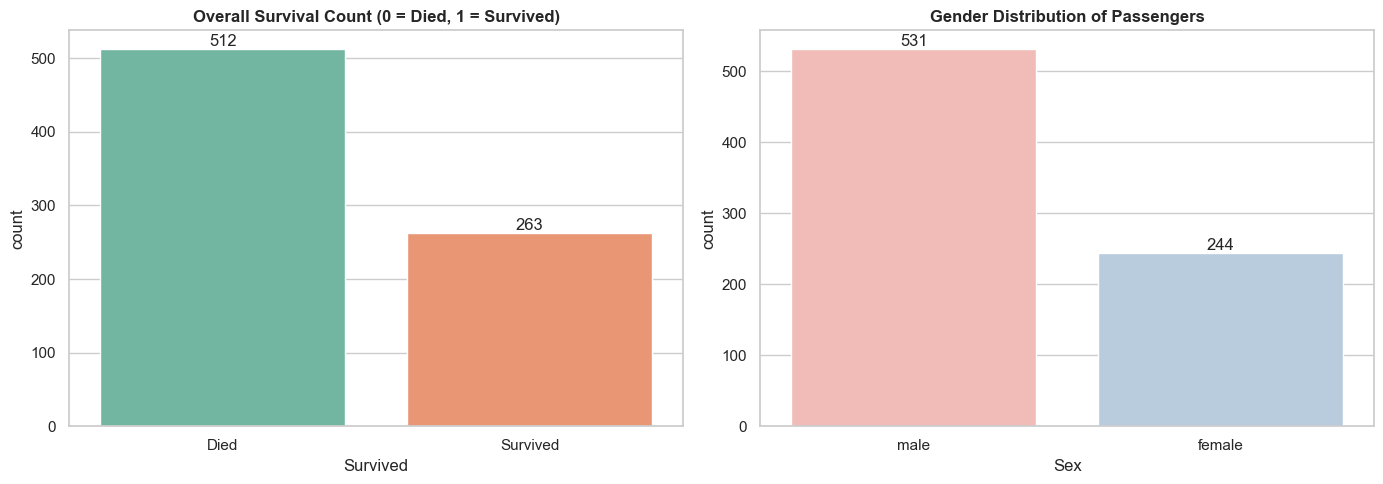

In [12]:
# ==========================================
# VISUALIZATION 1: BASELINE COUNTS
# ==========================================
import os

# Create the folder if you haven't already
os.makedirs('visualizations', exist_ok=True)

# Set global clean style
sns.set_theme(style="whitegrid")

# Set up a side-by-side plot area
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Survival Count
sns.countplot(x='Survived', data=df_cleaned, ax=axes[0], palette='Set2')
axes[0].set_title('Overall Survival Count (0 = Died, 1 = Survived)', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Died', 'Survived'])
for container in axes[0].containers:
    axes[0].bar_label(container)

# Plot 2: Gender Distribution
sns.countplot(x='Sex', data=df_cleaned, ax=axes[1], palette='Pastel1')
axes[1].set_title('Gender Distribution of Passengers', fontsize=12, fontweight='bold')
for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.savefig('visualizations/baseline_distributions.png', dpi=300)
plt.show()

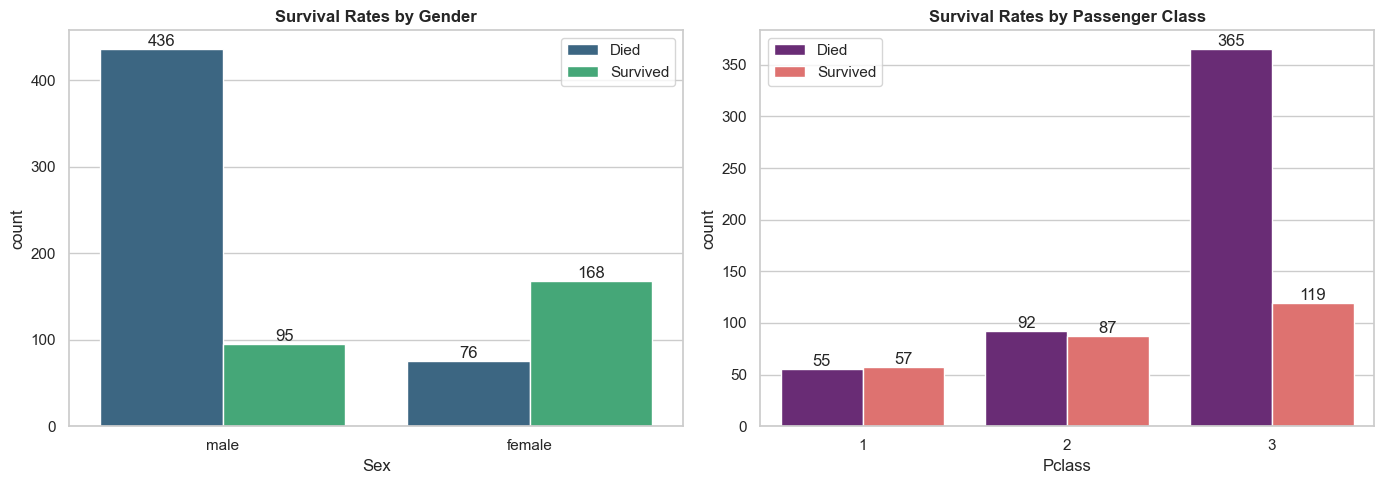

In [13]:
# ==========================================
# VISUALIZATION 2: SURVIVAL BY DEMOGRAPHICS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df_cleaned, ax=axes[0], palette='viridis')
axes[0].set_title('Survival Rates by Gender', fontsize=12, fontweight='bold')
axes[0].legend(['Died', 'Survived'])
for container in axes[0].containers:
    axes[0].bar_label(container)

# Plot 2: Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df_cleaned, ax=axes[1], palette='magma')
axes[1].set_title('Survival Rates by Passenger Class', fontsize=12, fontweight='bold')
axes[1].legend(['Died', 'Survived'])
for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.savefig('visualizations/survival_insights.png', dpi=300)
plt.show()

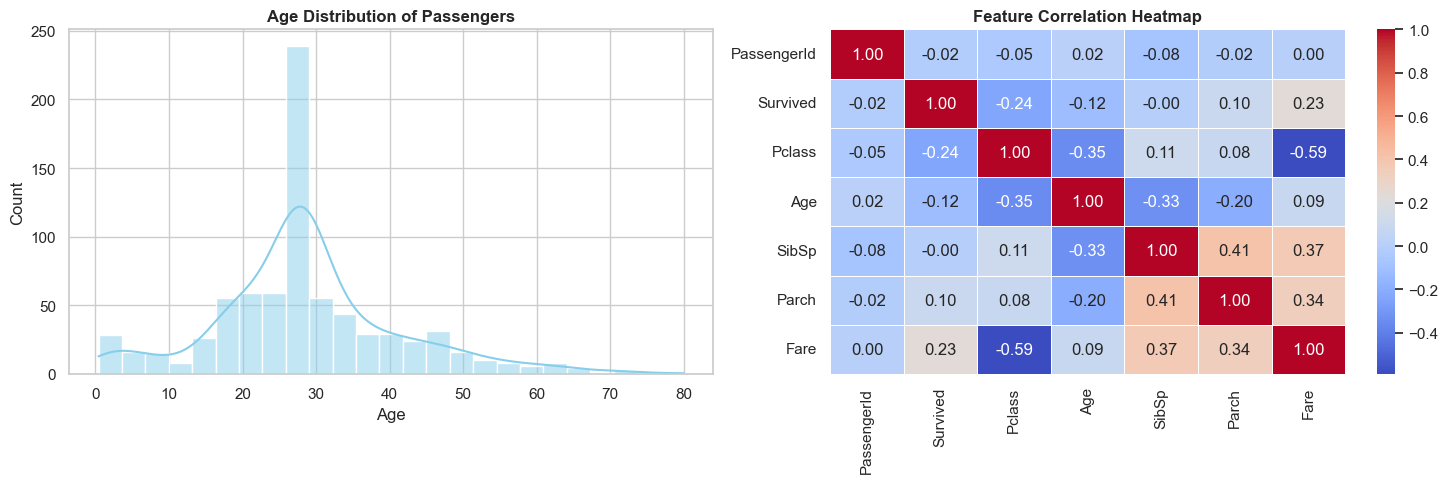

In [14]:
# ==========================================
# VISUALIZATION 3: AGE & CORRELATIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Age Distribution
sns.histplot(df_cleaned['Age'], bins=25, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution of Passengers', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')

# Plot 2: Correlation Heatmap
numeric_df = df_cleaned.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/age_and_correlation.png', dpi=300)
plt.show()